### Importing 

In [138]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [139]:
l1 = cv2.imread('stereo_materials/l1.png')
l1_gray = cv2.cvtColor(l1, cv2.COLOR_BGR2GRAY) #type: ignore
r1 = cv2.imread('stereo_materials/r1.png')
r1_gray = cv2.cvtColor(r1, cv2.COLOR_BGR2GRAY) #type: ignore

l2 = cv2.imread('stereo_materials/l2.png')
l2_gray = cv2.cvtColor(l2, cv2.COLOR_BGR2GRAY) #type: ignore
r2 = cv2.imread('stereo_materials/r2.png')
r2_gray = cv2.cvtColor(r2, cv2.COLOR_BGR2GRAY) #type: ignore

l3 = cv2.imread('stereo_materials/l3.png')
l3_gray = cv2.cvtColor(l3, cv2.COLOR_BGR2GRAY) #type: ignore
r3 = cv2.imread('stereo_materials/r3.png')
r3_gray = cv2.cvtColor(r3, cv2.COLOR_BGR2GRAY) #type: ignore

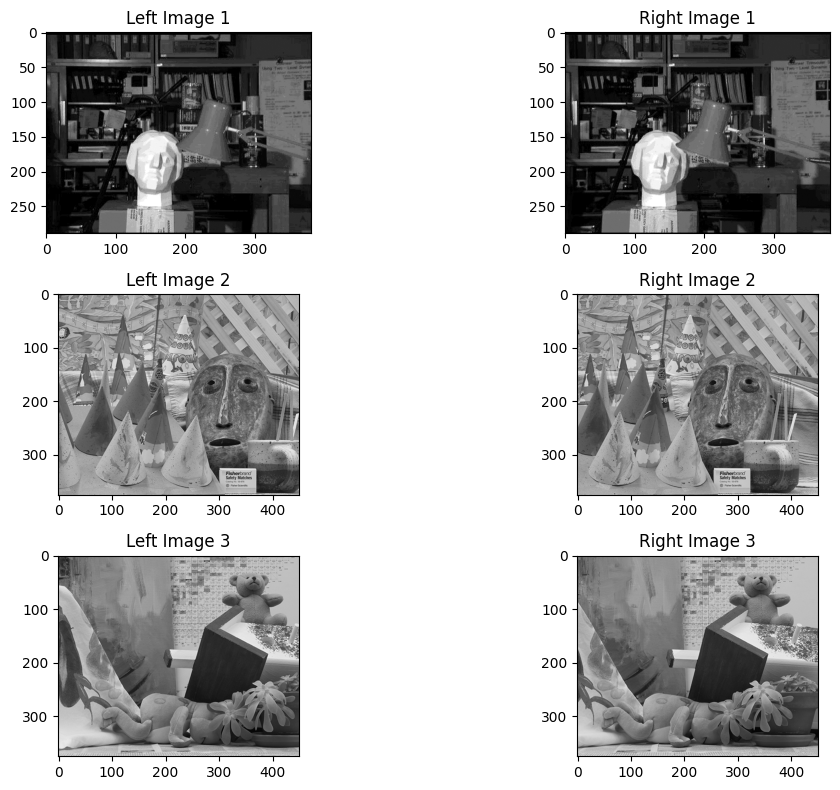

In [140]:
plt.figure(figsize=(12, 8))
plt.subplot(3, 2, 1)
plt.imshow(l1_gray, cmap='gray')
plt.title('Left Image 1')
plt.subplot(3, 2, 2)
plt.imshow(r1_gray, cmap='gray')
plt.title('Right Image 1')
plt.subplot(3, 2, 3)
plt.imshow(l2_gray, cmap='gray')
plt.title('Left Image 2')
plt.subplot(3, 2, 4)
plt.imshow(r2_gray, cmap='gray')
plt.title('Right Image 2')
plt.subplot(3, 2, 5)
plt.imshow(l3_gray, cmap='gray')
plt.title('Left Image 3')
plt.subplot(3, 2, 6)
plt.imshow(r3_gray, cmap='gray')
plt.title('Right Image 3')
plt.tight_layout()
plt.show()


### Block Matching
#### For each pixel (x,y) in the left image:

- Take a window around it (size w×w)
- Slide that window horizontally in the right image
- Compute a cost function
- Pick the shift d that gives the lowest cost
#### That **d** = disparity

In [141]:
def compute_disparity(Il, Ir, window_size, max_disp = 128, method="SAD"):
    h, w = Il.shape
    half = window_size // 2 # half window size for indexing
    disparity = np.zeros((h, w)) # initialize disparity map

    for y in range(half, h - half): # loop through each pixel, avoiding borders
        for x in range(half, w - half): 

            best_cost = float('inf')
            best_disp = 0

            left_block = Il[y-half:y+half+1, x-half:x+half+1] # extract block from left image
            left_block = left_block.astype(np.float32)
            for d in range(max_disp):
                if x - d - half < 0: # ensure we don't go out of bounds in the right image
                    break

                
                right_block = Ir[y-half:y+half+1, x-d-half:x-d+half+1]  # extract block from right image shifted by disparity d
                right_block = right_block.astype(np.float32)

                if method == "SAD":
                    cost = np.sum(np.abs(left_block - right_block))
                elif method == "SSD":
                    cost = np.sum((left_block - right_block) ** 2)

                if cost < best_cost:
                    best_cost = cost
                    best_disp = d

            disparity[y, x] = best_disp # assign best disparity for this pixel

    return disparity

In [142]:
def plot_disparity_map(disparity_map, title, max_disp):
    plt.imshow(disparity_map, cmap='gray', vmin=0, vmax=max_disp)
    plt.title(title)
    plt.colorbar(label='Disparity (pixels)')
    plt.axis('off')
    plt.show()

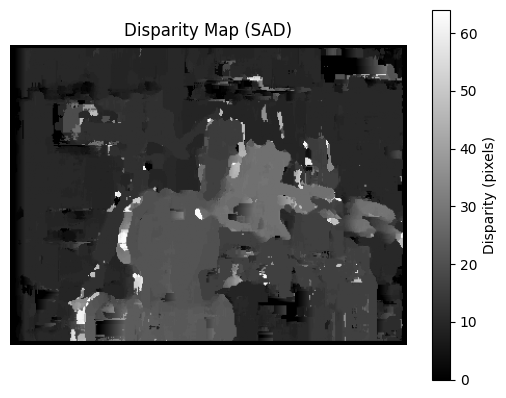

In [143]:
disparity_map1_SAD = compute_disparity(l1_gray, r1_gray, window_size=9, max_disp=64, method="SAD")
plot_disparity_map(disparity_map1_SAD, "Disparity Map (SAD)", 64)

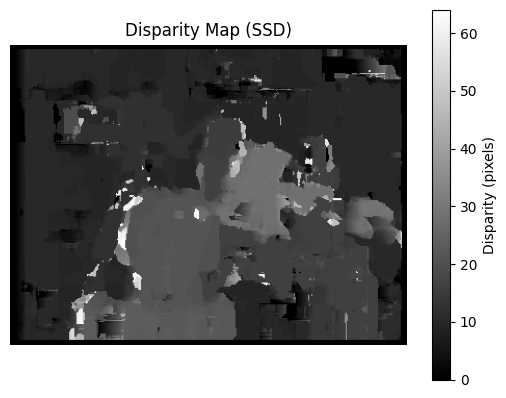

In [144]:
disparity_map2_SSD = compute_disparity(l1_gray, r1_gray, window_size=11, max_disp=64, method="SSD")
plot_disparity_map(disparity_map2_SSD, "Disparity Map (SSD)", 64 )

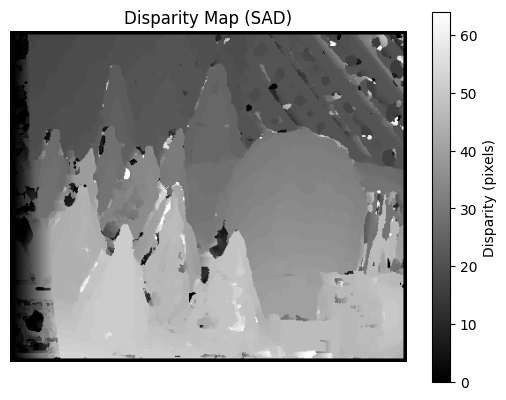

In [145]:
disparity_map3_SAD = compute_disparity(l2_gray, r2_gray, window_size=9, max_disp=64, method="SAD")
plot_disparity_map(disparity_map3_SAD, "Disparity Map (SAD)", 64)

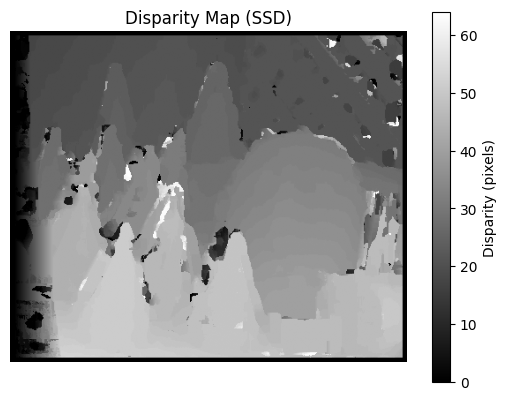

In [ ]:
disparity_map4_SSD = compute_disparity(l2_gray, r2_gray, window_size=9, max_disp=64, method="SSD")
plot_disparity_map(disparity_map4_SSD, "Disparity Map (SSD)", 64)

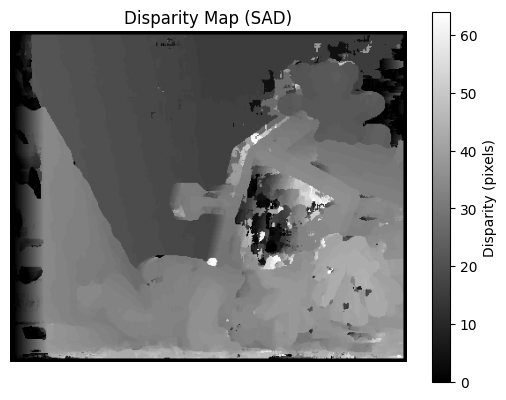

In [152]:
disparity_map5_SAD = compute_disparity(l3_gray, r3_gray, window_size=9, max_disp=64, method="SAD")
plot_disparity_map(disparity_map5_SAD, "Disparity Map (SAD)", 64)

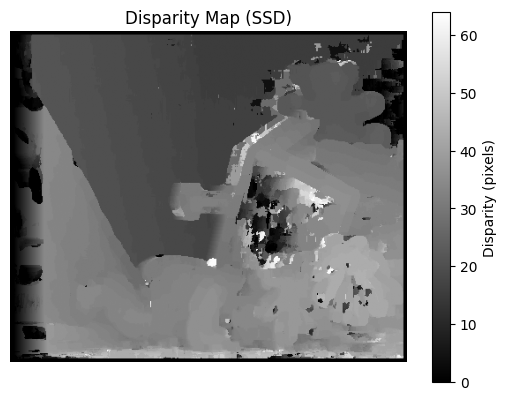

In [153]:
disparity_map6_SSD = compute_disparity(l3_gray, r3_gray, window_size=9, max_disp=64, method="SSD")
plot_disparity_map(disparity_map6_SSD, "Disparity Map (SSD)", 64)

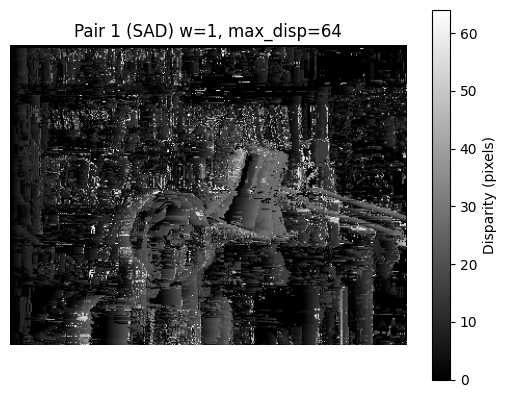

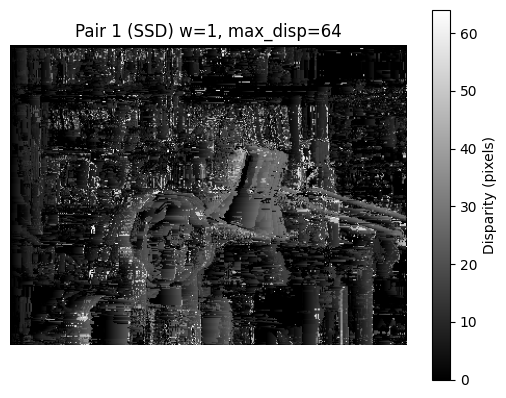

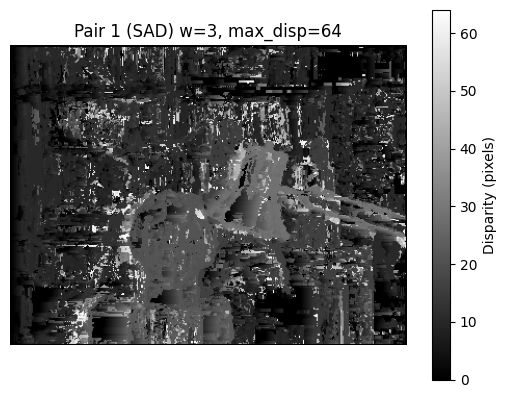

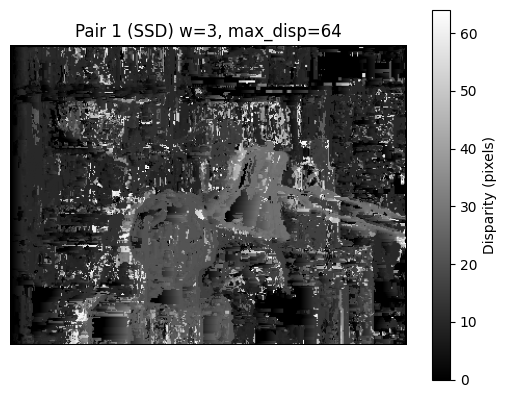

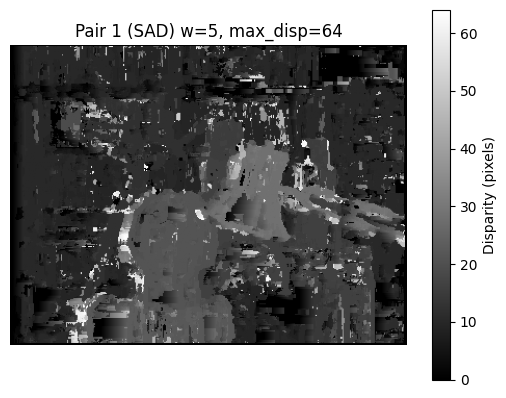

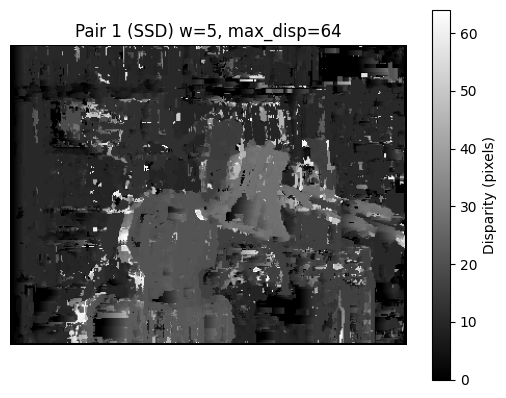

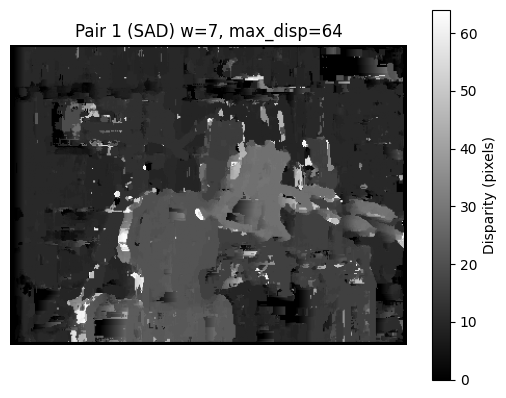

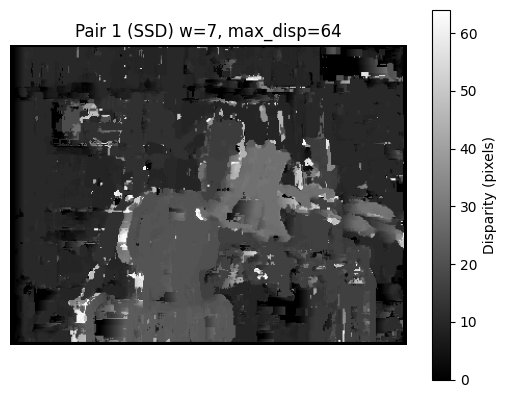

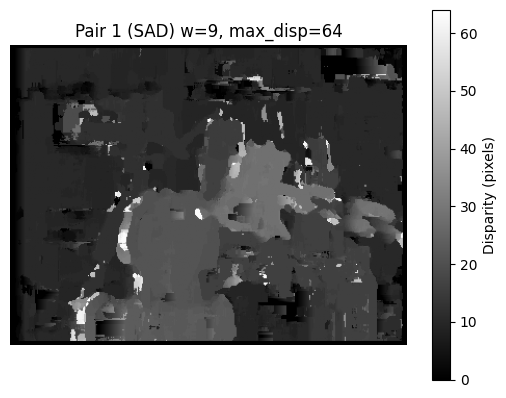

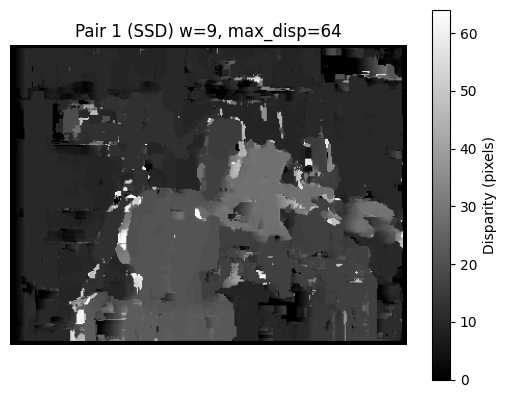

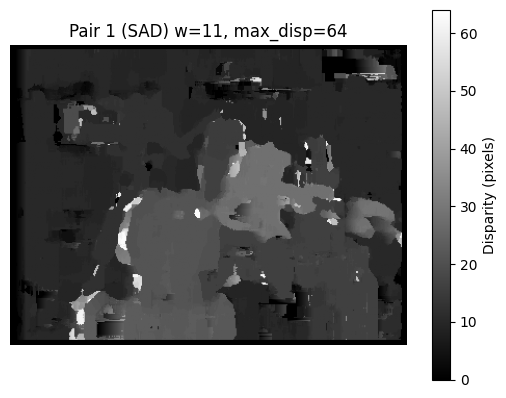

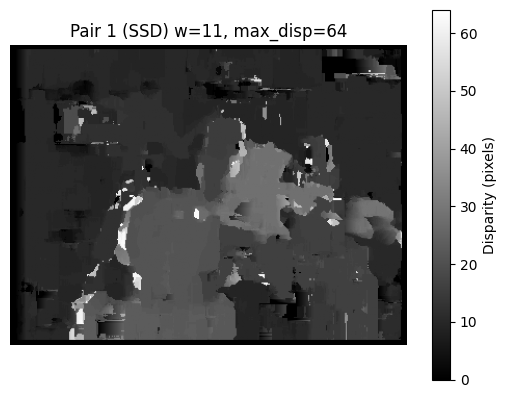

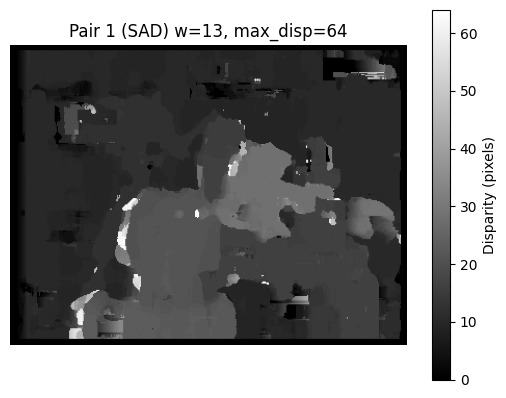

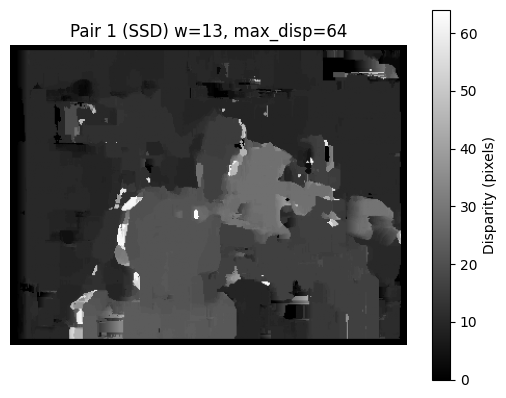

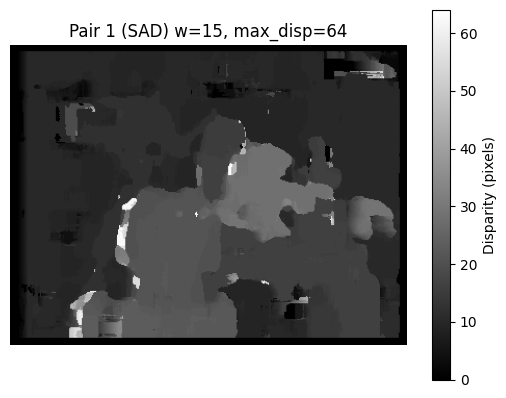

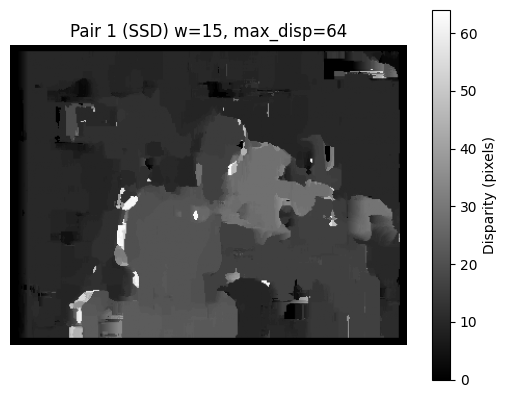

In [149]:
# Plot disparity for odd window sizes 1..15 with max_disp=64
max_disp = 64
window_sizes = range(1, 16, 2)
methods = ["SAD", "SSD"]

for w in window_sizes:
    for method in methods:
        disparity = compute_disparity(
            l1_gray,
            r1_gray,
            window_size=w,
            max_disp=max_disp,
            method=method,
        )
        plot_disparity_map(
            disparity,
            f"Pair 1 ({method}) w={w}, max_disp={max_disp}",
            max_disp,
        )